#### This is the script (using pytorch) created for model training. The model is built on a sequence labeling model using a Bidirectional LSTM with a CRF layer (for sequence labelling). The model is expected to process and label transitions as `<G>` for speaker shifts, `<B>` for backchannels, and `<O>` for overlaps. The model also ignores laughter, which is the interference for identifying backchannels and overlaps, treating it as non-transitional.

##### The model is trained to identify and annotate turn-taking transitions in frame-wise. Due to the lack of annotated data, this model could not be as functional as expected. Since the training size is quite small, we are adopting more epochs for the first training trial. The learning rate is by (0.0001). The loss function we are using is negtive log likelihood of CRF.



###### [Author] `Moana Chen`
###### [Date] `30.03.2025`

##### Installing the libraries and load them into kernel.

In [80]:
# !pip install 'praatio<5'
# !pip install soundfile
# !pip install librosa
# !pip install pytorch-crf
# !pip install torch torchvision torchaudio --extra-index-url https://download.pytorch.org/whl/nightly/cpu

In [34]:
import os
import glob
import numpy as np
import soundfile as sf  # or use torchaudio if you prefer
import librosa          # for audio processing / MFCC extraction
from praatio import tgio
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from torchcrf import CRF
import matplotlib.pyplot as plt
from collections import Counter

In [35]:
label2id = {"None": 0, "<G>": 1, "<B>": 2, "<O>": 3}
id2label = {v: k for k, v in label2id.items()}

In [36]:
# def extract_mfcc(filepath, sr=44100, frame_duration=0.1, n_mfcc=13): # we try every 10ms as one frame
#     audio, sample_rate = sf.read(filepath)
#     if audio.ndim > 1:
#         audio = np.mean(audio, axis=1)
#     if sample_rate != sr:
#         audio = librosa.resample(audio, orig_sr=sample_rate, target_sr=sr)
#         sample_rate = sr
#     hop_length = int(frame_duration * sr)  # e.g., 0.1s * 44100 = 4410
#     mfcc = librosa.feature.mfcc(
#         y=audio, sr=sample_rate, n_mfcc=n_mfcc, hop_length=hop_length, n_fft=hop_length
#     )  # shape: [n_mfcc, num_frames]
#     # treanspose to [num_frames, n_mfcc]
#     return mfcc.T  # shape: (num_frames, n_mfcc)

def create_label_sequence(textgrid_path, total_frames, frame_duration=0.1):
    """
    Generates a list of labels (strings) for each frame from a TextGrid file.
    We have a tier "transVals" with <G>, <B>, <O>, <L> (ignored), or no label.
    Returns a list of length total_frames, each element e.g. "None", "<G>", ...
    """
    try:
        tg = tgio.openTextgrid(textgrid_path)
    except Exception as e:
        print(f"Warning: Could not open {textgrid_path}: {e}")
        return ["None"] * total_frames

    # Adjust tier name in the annotated datasets
    if "transVals" not in tg.tierDict:
        # fallback or skip
        return ["None"] * total_frames
    tier = tg.tierDict["transVals"]
    intervals = tier.entryList  # (start, end, label)

    labels = ["None"] * total_frames

    for (start, end, lab) in intervals:
        lab = lab.strip()
        if lab == "<L>":
            continue  # ignore laughter
        if lab in ["<G>", "<B>", "<O>"]:
            start_frame = int(start / frame_duration)
            end_frame = int(end / frame_duration) + 1
            for i in range(start_frame, min(end_frame, total_frames)):
                labels[i] = lab
    return labels

In [37]:
def extract_mfcc_with_prosody(filepath, sr=44100, frame_duration=0.1, n_mfcc=13):
    audio_np, sample_rate = sf.read(filepath)
    if audio_np.ndim > 1:
        audio_np = np.mean(audio_np, axis=1)
    if sample_rate != sr:
        audio_np = librosa.resample(audio_np, orig_sr=sample_rate, target_sr=sr)
    hop_length = int(frame_duration * sr)
    # Extract MFCCs: (n_mfcc, num_frames)
    mfcc = librosa.feature.mfcc(y=audio_np, sr=sr, n_mfcc=n_mfcc, n_fft=hop_length, hop_length=hop_length)
    mfcc = mfcc.T  # (num_frames, n_mfcc)
    
    # Extract pitch using librosa.pyin (f0 estimates)
    f0, voiced_flag, voiced_prob = librosa.pyin(audio_np, fmin=librosa.note_to_hz('C2'),
                                                fmax=librosa.note_to_hz('C7'),
                                                sr=sr, hop_length=hop_length)
    # Replace NaNs with 0 (unvoiced)
    f0 = np.nan_to_num(f0, nan=0.0)
    f0 = f0.reshape(-1, 1)  # (num_frames, 1)
    
    # Extract RMS energy: shape (1, num_frames)
    rms = librosa.feature.rms(y=audio_np, hop_length=hop_length, frame_length=hop_length)
    rms = rms.T  # (num_frames, 1)
    
    # Concatenate features: now each frame has n_mfcc + 2 features.
    features = np.concatenate([mfcc, f0, rms], axis=1)  # shape: (num_frames, n_mfcc+2)
    return features

In [38]:
# def combine_features(as_mfcc, is_mfcc):
#     """
#     Given MFCC arrays [num_frames, n_mfcc] from each speaker,
#     horizontally concatenate them => shape [num_frames, 2*n_mfcc].
#     """
#     if as_mfcc.shape[0] != is_mfcc.shape[0]:
#         min_frames = min(as_mfcc.shape[0], is_mfcc.shape[0])
#         as_mfcc = as_mfcc[:min_frames]
#         is_mfcc = is_mfcc[:min_frames]
#     return np.concatenate([as_mfcc, is_mfcc], axis=1)

## when adding prosodic features we adjust the channels
def combine_features_with_prosody(as_mfcc, is_mfcc):
    """
    Given prosody-enhanced MFCC arrays from each speaker (each of shape (num_frames, n_mfcc+2)),
    horizontally concatenate them so that the resulting shape is (num_frames, 2*(n_mfcc+2)).
    If the two arrays have different numbers of frames, they are trimmed to the minimum length.
    """
    T = min(as_mfcc.shape[0], is_mfcc.shape[0])
    combined = np.concatenate([as_mfcc[:T], is_mfcc[:T]], axis=1)
    return combined



def combine_labels(as_labels, is_labels):
    """
    Merge two label sequences by priority: if as_label != 'None', use it,
    else use is_label.
    """
    merged = []
    for l_as, l_is in zip(as_labels, is_labels):
        if l_as != "None":
            merged.append(l_as)
        elif l_is != "None":
            merged.append(l_is)
        else:
            merged.append("None")
    return merged

#### Section for integrated function of mfcc extraction

In [39]:
class GBOAudioDataset(Dataset):
    def __init__(self, base_dir, frame_duration=0.1, sr=44100, n_mfcc=13):
        """
        base_dir: Path to a directory containing 'rec_*' subfolders.
                  Each subfolder contains matched AS/IS .wav files and corresponding .TextGrid files.
        This dataset extracts prosody-enhanced MFCC features from each channel and combines them.
        It also extracts labels from the "transVals" tier.
        """
        super().__init__()
        self.samples = []  # will store tuples: (feature_array, label_array)

        dyad_folders = glob.glob(os.path.join(base_dir, "rec_*"))
        for folder in dyad_folders:
            as_files = glob.glob(os.path.join(folder, "*_AS_*.wav"))
            is_files = glob.glob(os.path.join(folder, "*_IS_*.wav"))

            for as_file in as_files:
                base_as = os.path.basename(as_file)
                parts = base_as.split("_")
                pair_num = parts[1]
                part_id = parts[-1].split(".")[0] 

                matching_is = [f for f in is_files if f"rec_{pair_num}_IS_" in f and f"_{part_id}.wav" in f]
                if not matching_is:
                    continue
                is_file = matching_is[0]

                as_textgrid = as_file.replace(".wav", ".TextGrid")
                is_textgrid = is_file.replace(".wav", ".TextGrid")

                as_mfcc = extract_mfcc_with_prosody(as_file, sr=sr, frame_duration=frame_duration, n_mfcc=n_mfcc)
                is_mfcc = extract_mfcc_with_prosody(is_file, sr=sr, frame_duration=frame_duration, n_mfcc=n_mfcc)
                combined_feat = combine_features_with_prosody(as_mfcc, is_mfcc)  # shape: (T, 2*(n_mfcc+2))
                T = combined_feat.shape[0]

                labels_as = create_label_sequence(as_textgrid, T, frame_duration)
                labels_is = create_label_sequence(is_textgrid, T, frame_duration)
                merged_labels = combine_labels(labels_as, labels_is)

                label_ids = [label2id.get(lab, 0) for lab in merged_labels]

                self.samples.append((combined_feat, label_ids))
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        features, label_ids = self.samples[idx]
        # convert the features and labels to torch tensors.
        features_tensor = torch.from_numpy(features).float()  # shape: (T, 2*(n_mfcc+2))
        labels_tensor = torch.tensor(label_ids, dtype=torch.long)  # shape: (T,)
        return features_tensor, labels_tensor

##### Add masking

In [40]:
def collate_fn(batch): # masking
    """
    Custom collate function to pad variable-length sequences.

    batch: list of (features, labels) from GBOAudioDataset function
      features: (T, feature_dim)
      labels:   (T,)
    We want to combine them into:
      padded_features: (batch_size, max_len, feature_dim)
      padded_labels:   (batch_size, max_len)
      mask:            (batch_size, max_len) -> bool
    """
    # 1) to find max sequence length in this batch
    max_len = max(features.shape[0] for (features, labels) in batch)
    feature_dim = batch[0][0].shape[1]  # from the first sample

    padded_features = []
    padded_labels = []
    masks = []

    for (features, labels) in batch:
        seq_len = features.shape[0]

        padded_f = torch.zeros(max_len, feature_dim, dtype=torch.float)
        padded_f[:seq_len, :] = features

        padded_l = torch.zeros(max_len, dtype=torch.long)
        padded_l[:seq_len] = labels

        mask = torch.zeros(max_len, dtype=torch.bool)
        mask[:seq_len] = True

        padded_features.append(padded_f)
        padded_labels.append(padded_l)
        masks.append(mask)

    # stack them into final tensors of shape:
    # padded_features: (batch_size, max_len, feature_dim)
    # padded_labels:   (batch_size, max_len)
    # masks:           (batch_size, max_len)
    padded_features = torch.stack(padded_features, dim=0)
    padded_labels = torch.stack(padded_labels, dim=0)
    masks = torch.stack(masks, dim=0)

    return padded_features, padded_labels, masks

#### Define the desired Bidirectional LSTM model with CRF, and weighted/or not loss.

In [41]:
# import torch.nn as nn
# from torchcrf import CRF
# # the base BiLSTM WITHOUT ATTENTION.
# class BiLSTMCRFModel(nn.Module):
#     def __init__(self, input_dim, hidden_dim, n_labels, n_layers=1, dropout=0.1):
#         """
#         input_dim: Number of features per frame (e.g., 26 if combining 13 MFCCs from each speaker).
#         hidden_dim: Number of hidden units in the LSTM.
#         n_labels: Number of distinct labels (e.g., 4 for {"None","<G>","<B>","<O>"}).
#         n_layers: Number of stacked LSTM layers.
#         dropout: Dropout probability.
#         """
#         super().__init__()

#         self.lstm = nn.LSTM(
#             input_size=input_dim,
#             hidden_size=hidden_dim,
#             num_layers=n_layers,
#             batch_first=True,
#             bidirectional=True
#         )
#         self.dropout = nn.Dropout(dropout)
#         self.classifier = nn.Linear(hidden_dim * 2, n_labels)

#         # CRF with batch_first=True means the sequence dimension is dim=1.
#         self.crf = CRF(n_labels, batch_first=True)

#     def forward(self, x):
#         """
#         Forward pass for emission (logit) calculation only.
#         x: (batch_size, seq_len, input_dim)
#         Returns: (batch_size, seq_len, n_labels) - emission logits
#         """
#         lstm_out, _ = self.lstm(x)   # shape: (B, T, 2*hidden_dim)
#         lstm_out = self.dropout(lstm_out)
#         logits = self.classifier(lstm_out)  # shape: (B, T, n_labels)
#         return logits

#     def compute_loss(self, logits, tags, mask=None):
#         """
#         Compute the negative log-likelihood from the CRF layer.
#         logits: (B, T, n_labels)
#         tags:   (B, T) with integer label IDs
#         mask:   (B, T) bool tensor if you have variable-length sequences
#         Returns a scalar loss (mean over batch).
#         """
#         # The CRF layer's forward() returns the negative log likelihood
#         # We want to minimize the negative log likelihood => loss
#         nll = -self.crf.forward(logits, tags, mask=mask, reduction="mean")
#         return nll

#     def decode(self, logits, mask=None):
#         """
#         Decodes the best path (Viterbi) given emission logits.
#         logits: (B, T, n_labels)
#         Returns a list of lists of label IDs, one list per batch element.
#         """
#         # crf.decode returns a List[List[int]] of predicted labels
#         best_paths = self.crf.decode(logits, mask=mask)
#         return best_paths


In [42]:
# model with ATTENTION.
class BiLSTMCRFModelWithAttention(nn.Module):
    def __init__(self, input_dim, hidden_dim, n_labels, n_layers=1, dropout=0.1, num_heads=4):
        """
        input_dim: dimension of input features per frame (e.g., 26+4).
        hidden_dim: number of hidden units in the LSTM (per direction).
        n_labels: number of distinct labels (e.g., 4 for {"None", "<G>", "<B>", "<O>"}).
        n_layers: number of stacked LSTM layers.
        dropout: dropout probability.
        num_heads: number of heads for the self-attention layer.
        """
        super().__init__()
        # Bidirectional LSTM to extract sequential features
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=n_layers,
            batch_first=True,
            bidirectional=True
        )
        self.dropout = nn.Dropout(dropout)
        
        # We use batch_first=True so that input shape is (B, T, 2*hidden_dim).
        self.attention = nn.MultiheadAttention(
            embed_dim=hidden_dim * 2,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        
        # final classifier to produce logits for each time step.
        self.classifier = nn.Linear(hidden_dim * 2, n_labels)
        
        # add CRF layer for structured prediction
        self.crf = CRF(n_labels, batch_first=True)
    
    def forward(self, x, mask=None):
        """
        x: Tensor of shape (B, T, input_dim)
        mask: Optional boolean tensor of shape (B, T), where True indicates valid frames.
        Returns:logits: Tensor of shape (B, T, n_labels)
        """
        # forward
        lstm_out, _ = self.lstm(x)  # (B, T, 2*hidden_dim)
        lstm_out = self.dropout(lstm_out)
        
        # nn.MultiheadAttention expects a key_padding_mask with shape (B, T)
        # where True indicates positions that should be ignored
        if mask is not None:
            # key_padding_mask = ~mask will have True for padding
            attn_out, _ = self.attention(lstm_out, lstm_out, lstm_out, key_padding_mask=~mask)
            # add attention
            refined = lstm_out + attn_out
        else:
            refined = lstm_out
        
        # Classifier to produce logits
        logits = self.classifier(refined)  # (B, T, n_labels)
        return logits
    
    # def compute_loss(self, logits, tags, mask=None): # the negative log likelihood loss
    #     """
    #     Computes the negative log likelihood loss using the CRF
    #     logits: (B, T, n_labels)
    #     tags: (B, T) ground truth label indices
    #     Returns a scalar loss, then to average or total
    #     """
    #     # CRF forward() returns the log likelihood; we take its negative mean.
    #     nll = -self.crf.forward(logits, tags, mask=mask, reduction="mean")
    #     return nll
    
    def compute_loss(self, logits, tags, mask=None, class_weights=None): # new with the CRF Loss to Incorporate Class Weights
        token_loss = -self.crf.forward(logits, tags, mask=mask, reduction="none")  # shape: (B, T), adding the mask
        if class_weights is not None: # defined accroding to the distribution, linear
            weight_tensor = torch.tensor(class_weights, device=tags.device).float()  # shape: (n_labels,)
            weights = weight_tensor[tags]  # shape: (B, T)
            token_loss = token_loss * weights
            loss = token_loss.sum() / mask.sum()
        else:
            loss = token_loss.mean()
        return loss

    def decode(self, logits, mask=None):
        """
        Decodes the best label sequence via Viterbi using the CRF layer
        """
        return self.crf.decode(logits, mask=mask)

##### The two sections below are implementing the focal loss for experimental trials.

Formula: "FL(p_t​) = −α(1−p_t​)^γ \times log(p_t​)"

In [92]:
# class FocalLoss(nn.Module):
#     def __init__(self, gamma=2, alpha=None, reduction='mean', ignore_index=None):
#         super().__init__()
#         self.gamma = gamma
#         self.alpha = alpha
#         self.reduction = reduction
#         self.ignore_index = ignore_index
        
#     def forward(self, inputs, targets):
#         """
#         inputs: (N, C) where C = n_labels
#         targets: (N,) with integer class labels.
#         """
#         logpt = nn.functional.log_softmax(inputs, dim=1)  # (N, C)
#         pt = torch.exp(logpt)  # (N, C)
#         logpt = logpt.gather(1, targets.unsqueeze(1)).squeeze(1)
#         pt = pt.gather(1, targets.unsqueeze(1)).squeeze(1)
#         if self.alpha is not None:
#             if isinstance(self.alpha, (int, float)):
#                 alpha = torch.full_like(targets, self.alpha, dtype=inputs.dtype, device=inputs.device)
#             elif isinstance(self.alpha, list):
#                 alpha = torch.tensor(self.alpha, dtype=inputs.dtype, device=inputs.device)
#                 alpha = alpha[targets]
#             logpt = logpt * alpha
#         loss = - (1 - pt) ** self.gamma * logpt
#         if self.ignore_index is not None:
#             valid = (targets != self.ignore_index).float()
#             loss = loss * valid
#             if self.reduction == 'mean':
#                 return loss.sum() / valid.sum()
#             elif self.reduction == 'sum':
#                 return loss.sum()
#             else:
#                 return loss
#         else:
#             if self.reduction == 'mean':
#                 return loss.mean()
#             elif self.reduction == 'sum':
#                 return loss.sum()
#             else:
#                 return loss

In [93]:
# def train_model_with_focal(dataset, device, num_epochs=50, batch_size=2):
#     dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
#     input_dim = 2 * (13)  # if only MFCCs: 13 from each channel = 26 features
#     # If you add prosodic features, update input_dim accordingly.
#     hidden_dim = 64
#     n_labels = 4
#     model = BiLSTMModelWithAttention(input_dim, hidden_dim, n_labels, n_layers=1, dropout=0.1, num_heads=4).to(device)
    
#     optimizer = optim.Adam(model.parameters(), lr=1e-4)
#     # Example alpha values: you can tune these. Here, we assign a higher weight to minority classes.
#     focal_loss = FocalLoss(gamma=2, alpha=[1, 2, 2, 2], reduction='mean', ignore_index=0)
    
#     for epoch in range(num_epochs):
#         model.train()
#         total_loss = 0.0
#         for features, labels, mask in dataloader:
#             features = features.to(device)
#             labels = labels.to(device)
#             mask = mask.to(device)
            
#             optimizer.zero_grad()
#             logits = model(features, mask=mask)  # (B, T, n_labels)
#             # Flatten logits and labels to compute loss over all valid tokens.
#             B, T, C = logits.shape
#             logits_flat = logits.view(-1, C)
#             labels_flat = labels.view(-1)
            
#             loss = focal_loss(logits_flat, labels_flat)
#             loss.backward()
#             optimizer.step()
#             total_loss += loss.item()
        
#         avg_loss = total_loss / len(dataloader)
#         print(f"Epoch {epoch+1}/{num_epochs} - Loss: {avg_loss:.4f}")
    
#     return model

#### Here we mount and add read/write path, and start to load the data to the dataset variable.

In [43]:
# mount google drive
# from google.colab import drive
# drive.mount('/content/drive')

base_dir = "/Users/moanason/Downloads/GBO_audio_train"

dataset = GBOAudioDataset(base_dir)
print("Number of samples:", len(dataset))

# saving dir of the .pt
# save_dir = "/Users/moanason/Downloads/GBO/Models"
# os.makedirs(save_dir, exist_ok=True)  # Create the directory if it doesn't exist

Number of samples: 4


In [54]:
import torch
from torch.utils.data import DataLoader

def train_epoch(model, dataloader, optimizer, device):
    model.train()
    total_loss = 0.0

    for batch_idx, (features, labels, mask) in enumerate(dataloader):

        features = features.to(device)
        labels = labels.to(device)
        mask = mask.to(device)

        optimizer.zero_grad()

        logits = model(features)  # shape: (B, max_len, n_labels)

        loss = model.compute_loss(logits, labels, mask=mask)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)

def evaluate(model, dataloader, device):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for features, labels, mask in dataloader:
            features = features.to(device)
            labels = labels.to(device)
            mask = mask.to(device)

            logits = model(features)
            loss = model.compute_loss(logits, labels, mask=mask)
            total_loss += loss.item()
    return total_loss / len(dataloader)


#### Define the model trainng loop with hyperparameters.

##### Model without weighing for labels considering uneven distribution.

In [ ]:
def train_model():
    device = torch.device("mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu"))

    print("Using device:", device)

    # Then:
    from torch.utils.data import random_split

    if len(dataset) > 1:
        train_size = int(0.8 * len(dataset)) # split for training and validation
        val_size = len(dataset) - train_size
        train_data, val_data = random_split(dataset, [train_size, val_size])

        train_loader = DataLoader(train_data, batch_size=2, shuffle=True, collate_fn=collate_fn)
        val_loader = DataLoader(val_data, batch_size=2, shuffle=False, collate_fn=collate_fn)
    else:
        train_loader = DataLoader(dataset, batch_size=1, shuffle=True) # in case one sample only in the dataset
        val_loader = None

    # hyperparameters
    n_mfcc = 13
    # input_dim = 2 * n_mfcc     # here is 13 MFCC * 2 speakers, as extracted
    input_dim = 2 * (n_mfcc + 2) # we add two features: pitch, RMS energy
    hidden_dim = 64
    n_labels = 4

    model = BiLSTMCRFModelWithAttention(input_dim, hidden_dim, n_labels, n_layers=2, dropout=0.1, num_heads=4).to(device) # we used one for the first tryon

    optimizer = torch.optim.Adam(model.parameters(), lr=4e-3)

    num_epochs = 100
    patience = 5 
    best_val_loss = float('inf')
    patience_counter = 0

    # save checkpoints
    save_dir = "/Users/moanason/Downloads/GBO/models/checkpoints"
    os.makedirs(save_dir, exist_ok=True)

    for epoch in range(num_epochs):
        train_loss = train_epoch(model, train_loader, optimizer, device)
        if val_loader is not None:
            val_loss = evaluate(model, val_loader, device)
        else:
            val_loss = train_loss  # if no validation data, use train_loss, though we split already

        print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            checkpoint_path = os.path.join(save_dir, "model_crf_gbo_m30.pt")
            torch.save(model.state_dict(), checkpoint_path)
            print(f"Validation loss improved. Checkpoint saved at epoch {epoch+1}.")
        else:
            patience_counter += 1
            print(f"No improvement in validation loss. Patience counter: {patience_counter}/{patience}")
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break

    return model

In [97]:
if __name__ == "__main__":
    train_model()

Using device: mps
Epoch [1/100] - Train Loss: 8302.3818, Val Loss: 6732.4238
Validation loss improved. Checkpoint saved at epoch 1.
Epoch [2/100] - Train Loss: 6930.6689, Val Loss: 5613.3271
Validation loss improved. Checkpoint saved at epoch 2.
Epoch [3/100] - Train Loss: 5781.6133, Val Loss: 4587.5630
Validation loss improved. Checkpoint saved at epoch 3.
Epoch [4/100] - Train Loss: 4827.6953, Val Loss: 3718.0195
Validation loss improved. Checkpoint saved at epoch 4.
Epoch [5/100] - Train Loss: 4129.1675, Val Loss: 3139.2529
Validation loss improved. Checkpoint saved at epoch 5.
Epoch [6/100] - Train Loss: 3747.5171, Val Loss: 2877.4141
Validation loss improved. Checkpoint saved at epoch 6.
Epoch [7/100] - Train Loss: 3652.2202, Val Loss: 2825.7197
Validation loss improved. Checkpoint saved at epoch 7.
Epoch [8/100] - Train Loss: 3707.6218, Val Loss: 2833.2354
No improvement in validation loss. Patience counter: 1/5
Epoch [9/100] - Train Loss: 3749.9497, Val Loss: 2838.8711
No improv

##### Resume/Add training loops if epoch not sufficient.

In [ ]:
def continue_training(additional_epochs=50, new_lr=5e-3, patience=5):
    device = torch.device("mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu"))
    print("Using device:", device)

    from torch.utils.data import random_split

    n_mfcc = 13
    # input_dim = 2 * n_mfcc     # here is 13 MFCC * 2 speakers, as extracted
    input_dim = 2 * (n_mfcc + 2) # we add two features: pitch, RMS energy
    hidden_dim = 64
    n_labels = 4
    model = BiLSTMCRFModelWithAttention(input_dim, hidden_dim, n_labels, n_layers=2, dropout=0.1, num_heads=4).to(device)

    state_dict = torch.load("/Users/moanason/Downloads/GBO/models/checkpoints/model_crf_gbo_m30.pt", map_location=device)
    model.load_state_dict(state_dict)

    # a NEW optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=new_lr)

    if len(dataset) > 1:
        train_size = int(0.8 * len(dataset))
        val_size = len(dataset) - train_size
        train_data, val_data = random_split(dataset, [train_size, val_size])

        train_loader = DataLoader(train_data, batch_size=2, shuffle=True, collate_fn=collate_fn)
        val_loader = DataLoader(val_data, batch_size=2, shuffle=False, collate_fn=collate_fn)
    else:
        train_loader = DataLoader(dataset, batch_size=1, shuffle=True, collate_fn=collate_fn)
        val_loader = None

    best_val_loss = float("inf")
    epochs_without_improvement = 0
    total_epochs = additional_epochs

    for epoch in range(total_epochs):
        train_loss = train_epoch(model, train_loader, optimizer, device)
        val_loss = evaluate(model, val_loader, device)

        print(f"Additional Epoch [{epoch+1}/{total_epochs}] - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_without_improvement = 0
            checkpoint = {
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_loss": val_loss
            }
            torch.save(checkpoint, "best_bilstm_crf_model.pt")
            print(f"Model improved and saved at epoch {epoch+1} with Val Loss: {val_loss:.4f}")
        else:
            epochs_without_improvement += 1
            print(f"No improvement for {epochs_without_improvement} epoch(s).")
        if epochs_without_improvement >= patience:
            print(f"Early stopping triggered after {patience} epochs without improvement.")
            break

    save_dir = "/Users/moanason/Downloads/GBO/models/checkpoints"
    os.makedirs(save_dir, exist_ok=True)
    model_save_path = os.path.join(save_dir, "model_crf_gbo_tuned05.pt")
    torch.save(model.state_dict(), model_save_path)
    print("Finished additional training and saved final weights to model_crf_gbo_tuned.pt")

    return model

In [99]:
continue_training(additional_epochs=50, new_lr=5e-3, patience=5)

Using device: mps
Additional Epoch [1/50] - Train Loss: 3009.4238, Val Loss: 4583.3535
Model improved and saved at epoch 1 with Val Loss: 4583.3535
Additional Epoch [2/50] - Train Loss: 2679.0667, Val Loss: 3892.7041
Model improved and saved at epoch 2 with Val Loss: 3892.7041
Additional Epoch [3/50] - Train Loss: 2417.5408, Val Loss: 4171.5303
No improvement for 1 epoch(s).
Additional Epoch [4/50] - Train Loss: 2277.0127, Val Loss: 3334.1318
Model improved and saved at epoch 4 with Val Loss: 3334.1318
Additional Epoch [5/50] - Train Loss: 2009.2498, Val Loss: 3119.5430
Model improved and saved at epoch 5 with Val Loss: 3119.5430
Additional Epoch [6/50] - Train Loss: 2105.9827, Val Loss: 3253.0225
No improvement for 1 epoch(s).
Additional Epoch [7/50] - Train Loss: 1873.6504, Val Loss: 2848.5273
Model improved and saved at epoch 7 with Val Loss: 2848.5273
Additional Epoch [8/50] - Train Loss: 1671.9895, Val Loss: 2715.4160
Model improved and saved at epoch 8 with Val Loss: 2715.4160
Ad

BiLSTMCRFModelWithAttention(
  (lstm): LSTM(30, 64, num_layers=2, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.1, inplace=False)
  (attention): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
  )
  (classifier): Linear(in_features=128, out_features=4, bias=True)
  (crf): CRF(num_tags=4)
)

##### Model training loop with weighted values.

Label counts: Counter({0: 20461, 1: 1679, 3: 984, 2: 880})


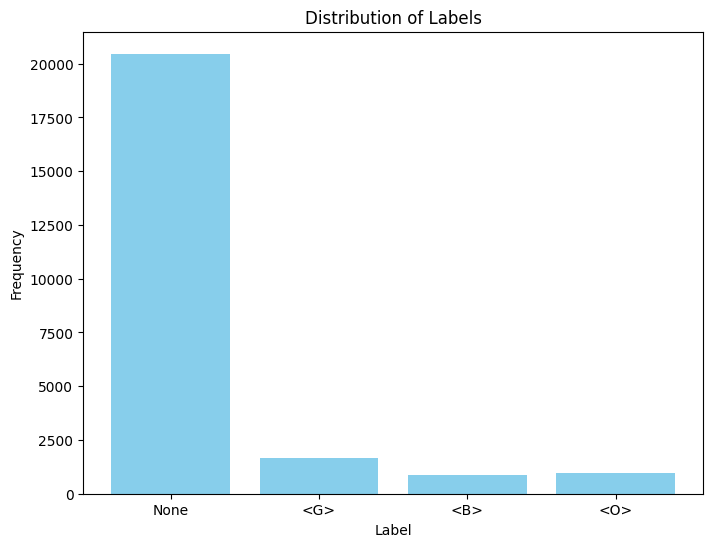

In [55]:
def get_label_distribution(dataset):
    all_labels = []
    for i in range(len(dataset)):
        _, labels = dataset[i]
        all_labels.extend(labels.numpy().tolist())
    return Counter(all_labels)

counter = get_label_distribution(dataset)
print("Label counts:", counter)

labels_sorted = sorted(counter.keys())
label_names = [id2label[label_id] for label_id in labels_sorted]
counts = [counter[label_id] for label_id in labels_sorted]

# plot distribution
plt.figure(figsize=(8, 6))
plt.bar(label_names, counts, color='skyblue')
plt.xlabel("Label")
plt.ylabel("Frequency")
plt.title("Distribution of Labels")
plt.show()

In [66]:
from torch.utils.data import DataLoader

def train_epoch(model, train_loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    for features, labels, mask in train_loader:
        features = features.to(device)  # (B, T, input_dim)
        labels = labels.to(device)      # (B, T)
        mask = mask.to(device)          # (B, T)
        
        optimizer.zero_grad()
        logits = model(features, mask=mask)  # (B, T, n_labels)
        B, T, C = logits.shape
        # Flatten logits and labels to (B*T, n_labels) and (B*T)
        logits_flat = logits.view(-1, C)
        targets_flat = labels.view(-1)
        
        loss = criterion(logits_flat, targets_flat)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    avg_train_loss = total_loss / len(train_loader)
    return avg_train_loss

def evaluate_epoch(model, val_loader, criterion, device):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for features, labels, mask in val_loader:
            features = features.to(device)
            labels = labels.to(device)
            mask = mask.to(device)
            logits = model(features, mask=mask)
            B, T, C = logits.shape
            logits_flat = logits.view(-1, C)
            targets_flat = labels.view(-1)
            loss = criterion(logits_flat, targets_flat)
            total_loss += loss.item()
    avg_val_loss = total_loss / len(val_loader)
    return avg_val_loss


In [67]:
def train_model_weighted(num_epochs=100, batch_size=2, patience=5):
    device = torch.device("mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu"))
    print("Using device:", device)

    from torch.utils.data import random_split

    if len(dataset) > 1:
        train_size = int(0.8 * len(dataset))
        val_size = len(dataset) - train_size
        train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)
    else:
        train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
        val_loader = None
    
    # Model hyperparameters.
    n_mfcc = 13
    # input_dim = 2 * n_mfcc     # here is 13 MFCC * 2 speakers, as extracted
    input_dim = 2 * (n_mfcc + 2) # we add two features: pitch, RMS energy
    hidden_dim = 64
    n_labels = 4 
    
    model = BiLSTMCRFModelWithAttention(input_dim, hidden_dim, n_labels, n_layers=1, dropout=0.1, num_heads=4).to(device)
    
    # load class weights
    class_weights = torch.tensor([1.0, 3.5, 4.8, 4.6], device=device).float()
    PAD_index = 0
    criterion = nn.CrossEntropyLoss(weight=class_weights, ignore_index=PAD_index)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=5e-3)
    
    best_val_loss = float('inf')
    patience_counter = 0
    
    for epoch in range(num_epochs):
        train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
        if val_loader is not None:
            val_loss = evaluate_epoch(model, val_loader, criterion, device)
        else:
            val_loss = train_loss

        print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

        # save checkpoints directory
        save_dir = "/Users/moanason/Downloads/GBO/models/checkpoints"
        os.makedirs(save_dir, exist_ok=True)

        if val_loss < best_val_loss: # checkpoints
            best_val_loss = val_loss
            patience_counter = 0
            checkpoint_path = os.path.join(save_dir, "model_crf_gbo_we4.pt")
            torch.save(model.state_dict(), checkpoint_path)
            print(f"Epoch {epoch+1}: Validation loss improved. Checkpoint saved.")
        else:
            patience_counter += 1
            print(f"Epoch {epoch+1}: No improvement in validation loss. Patience counter: {patience_counter}/{patience}")
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break
    
    return model

In [68]:
if __name__ == "__main__":
    device = torch.device("mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu"))
    trained_model = train_model_weighted(num_epochs=100, batch_size=2, patience=5)

Using device: mps
Epoch 1/100 - Train Loss: 1.3032, Val Loss: 1.1260
Epoch 1: Validation loss improved. Checkpoint saved.
Epoch 2/100 - Train Loss: 0.9310, Val Loss: 1.1986
Epoch 2: No improvement in validation loss. Patience counter: 1/5
Epoch 3/100 - Train Loss: 0.7870, Val Loss: 0.9584
Epoch 3: Validation loss improved. Checkpoint saved.
Epoch 4/100 - Train Loss: 0.7031, Val Loss: 1.2544
Epoch 4: No improvement in validation loss. Patience counter: 1/5
Epoch 5/100 - Train Loss: 0.6793, Val Loss: 0.9249
Epoch 5: Validation loss improved. Checkpoint saved.
Epoch 6/100 - Train Loss: 0.6353, Val Loss: 0.9077
Epoch 6: Validation loss improved. Checkpoint saved.
Epoch 7/100 - Train Loss: 0.5937, Val Loss: 1.2231
Epoch 7: No improvement in validation loss. Patience counter: 1/5
Epoch 8/100 - Train Loss: 0.5757, Val Loss: 1.1487
Epoch 8: No improvement in validation loss. Patience counter: 2/5
Epoch 9/100 - Train Loss: 0.6168, Val Loss: 0.9177
Epoch 9: No improvement in validation loss. Pat

In [100]:
# import os
# print(os.getcwd())
# print(os.listdir('.'))

#### Evaluation Starts Here
---------------------------------------------------------------------------

In [69]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model_with_confusion(test_dataset, model_path, device, batch_size=2):
    # test_dataset = GBOAudioDataset(base_dir=test_base_dir, frame_duration=0.1, sr=44100, n_mfcc=13)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
    
    n_mfcc = 13
    # input_dim = 2 * n_mfcc     # here is 13 MFCC * 2 speakers, as extracted
    input_dim = 2 * (n_mfcc + 2) # we add two features: pitch, RMS energy
    hidden_dim = 64
    n_labels = 4
    model = BiLSTMCRFModelWithAttention(input_dim, hidden_dim, n_labels, n_layers=1, dropout=0.1, num_heads=4).to(device)

    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()
    print(f"Loaded model from {model_path}")
    
    all_gold = []
    all_pred = []
    
    with torch.no_grad():
        for batch in test_loader:
            if len(batch) == 3:
                features, labels, mask = batch
            elif len(batch) >= 4:
                features, _, _, labels, mask = batch
            else:
                features, labels = batch
                mask = torch.ones_like(labels, dtype=torch.bool)
            
            features = features.to(device)
            labels = labels.to(device)
            mask = mask.to(device)
            
            logits = model(features)  # shape: (B, T, n_labels)
            pred_batch = model.decode(logits, mask=mask)  # List of lists of predicted label IDs
            
            for i in range(features.size(0)):
                seq_len = int(mask[i].sum().item())  # number of valid frames
                gold_seq = labels[i][:seq_len].cpu().numpy().tolist()
                pred_seq = pred_batch[i][:seq_len]
                all_gold.extend(gold_seq)
                all_pred.extend(pred_seq)
    
    accuracy = accuracy_score(all_gold, all_pred)
    f1 = f1_score(all_gold, all_pred, average='macro')
    
    # load confusion matrix
    cm = confusion_matrix(all_gold, all_pred, labels=[0, 1, 2, 3])
    print("Confusion Matrix:")
    print(cm)
    
    report = classification_report(all_gold, all_pred, target_names=["None", "<G>", "<B>", "<O>"])
    print("Classification Report:")
    print(report)
    
    print(f"Token-level Accuracy: {accuracy:.4f}")
    print(f"Macro F1 Score: {f1:.4f}")
    
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["None", "<G>", "<B>", "<O>"], yticklabels=["None", "<G>", "<B>", "<O>"])
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()
    
    return accuracy, f1, cm, report

In [32]:
test_base_dir = "/Users/moanason/Downloads/GBO_audio_eval" 
test_dataset = GBOAudioDataset(base_dir=test_base_dir, frame_duration=0.1, sr=44100, n_mfcc=13)
print(len(test_dataset))

2


Using device: mps
Loaded model from /Users/moanason/Downloads/GBO/models/checkpoints/model_crf_gbo_we4.pt
Confusion Matrix:
[[   0 2717 1466 6421]
 [   0  516   50   61]
 [   0   45   46  200]
 [   0    7   17  456]]
Classification Report:
              precision    recall  f1-score   support

        None       0.00      0.00      0.00     10604
         <G>       0.16      0.82      0.26       627
         <B>       0.03      0.16      0.05       291
         <O>       0.06      0.95      0.12       480

    accuracy                           0.08     12002
   macro avg       0.06      0.48      0.11     12002
weighted avg       0.01      0.08      0.02     12002

Token-level Accuracy: 0.0848
Macro F1 Score: 0.1082


/Users/moanason/anaconda3/envs/torchpy/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/moanason/anaconda3/envs/torchpy/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/moanason/anaconda3/envs/torchpy/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.

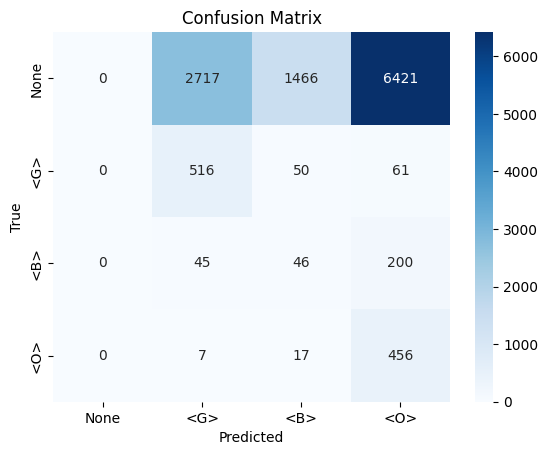

In [70]:
if __name__ == "__main__":
    model_path = "/Users/moanason/Downloads/GBO/models/checkpoints/model_crf_gbo_we4.pt"
    device = torch.device("mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu"))
    print("Using device:", device)
    evaluate_model_with_confusion(test_dataset, model_path, device, batch_size=2)